# 🏠 Predicting House Prices with Linear Regression

**Objective:** Build and evaluate a linear regression model that predicts house prices
based on features such as area, location, number of rooms, and age.

**Dataset:** [House Prices: Advanced Regression Techniques](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques)
(Kaggle)


## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 2. Load Dataset

We try to load the real Kaggle `train.csv`. If it isn't present, we generate a
synthetic dataset that mimics the same kind of features (area, location, rooms,
age) so the notebook still runs fully.


In [2]:
import os

DATA_PATH = "train.csv"

def generate_synthetic_housing_data(n=1200, seed=RANDOM_STATE):
    """Creates a synthetic housing dataset with realistic relationships,
    used only as a fallback when train.csv is not available."""
    rng = np.random.default_rng(seed)

    locations = ["Downtown", "Suburb_A", "Suburb_B", "Rural", "Uptown"]
    location_premium = {"Downtown": 60000, "Suburb_A": 20000,
                         "Suburb_B": 10000, "Rural": -20000, "Uptown": 45000}

    area = rng.normal(1800, 600, n).clip(400, 6000)               # sq ft
    rooms = rng.integers(1, 7, n)                                  # bedrooms
    bathrooms = rng.integers(1, 4, n)
    age = rng.integers(0, 100, n)                                  # years old
    location = rng.choice(locations, n)
    garage = rng.integers(0, 3, n)
    lot_size = area * rng.uniform(1.0, 2.5, n)

    # Introduce some missing values to practice cleaning
    df = pd.DataFrame({
        "Area_sqft": area,
        "Bedrooms": rooms,
        "Bathrooms": bathrooms,
        "Age_years": age,
        "Location": location,
        "GarageSpaces": garage,
        "LotSize_sqft": lot_size,
    })

    missing_idx = rng.choice(df.index, size=int(0.03 * n), replace=False)
    df.loc[missing_idx, "Area_sqft"] = np.nan
    missing_idx2 = rng.choice(df.index, size=int(0.02 * n), replace=False)
    df.loc[missing_idx2, "LotSize_sqft"] = np.nan

    # Price = weighted combination of features + location premium + noise
    base_price = (
        120 * df["Area_sqft"].fillna(df["Area_sqft"].mean())
        + 8000 * df["Bedrooms"]
        + 12000 * df["Bathrooms"]
        - 800 * df["Age_years"]
        + 5000 * df["GarageSpaces"]
        + 2 * df["LotSize_sqft"].fillna(df["LotSize_sqft"].mean())
        + df["Location"].map(location_premium)
        + 50000
    )
    noise = rng.normal(0, 15000, n)
    df["Price"] = (base_price + noise).clip(30000, None).round(0)

    return df

if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    # Kaggle's column is "SalePrice" -- standardize to "Price" for this notebook
    if "SalePrice" in df.columns and "Price" not in df.columns:
        df = df.rename(columns={"SalePrice": "Price"})
    print(f"Loaded real dataset from {DATA_PATH} -> shape {df.shape}")
else:
    df = generate_synthetic_housing_data()
    print("train.csv not found — using synthetic dataset instead.")
    print(f"Synthetic dataset shape: {df.shape}")

df.head()


train.csv not found — using synthetic dataset instead.
Synthetic dataset shape: (1200, 8)


,Area_sqft,Bedrooms,Bathrooms,Age_years,Location,GarageSpaces,LotSize_sqft,Price
0,1982.830248,3,2,5,Rural,1,NaN,323164.0
1,1176.009536,2,1,58,Rural,2,2707.447069,194864.0
2,NaN,1,2,19,Uptown,0,4062.863573,346366.0
3,2364.338830,3,2,66,Downtown,0,4688.389976,402904.0
4,629.378887,4,2,41,Suburb_A,0,1368.596507,170478.0


## 3. Exploratory Data Analysis (EDA)

- Null value check
- Descriptive statistics
- Distribution of the target variable (`Price`)


In [3]:
# --- Null check ---
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(2)
null_summary = pd.DataFrame({"missing_count": null_counts, "missing_pct": null_pct})
null_summary = null_summary[null_summary["missing_count"] > 0].sort_values("missing_count", ascending=False)
print("Columns with missing values:")
null_summary


Columns with missing values:


,missing_count,missing_pct
Area_sqft,36,3.0
LotSize_sqft,24,2.0


In [4]:
# --- Descriptive statistics ---
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Area_sqft,1164.0,NaN,NaN,NaN,1793.230473,588.587133,400.0,1405.486387,1806.869019,2170.442057,3707.312208
Bedrooms,1200.0,NaN,NaN,NaN,3.524167,1.701027,1.0,2.0,3.0,5.0,6.0
Bathrooms,1200.0,NaN,NaN,NaN,1.968333,0.824356,1.0,1.0,2.0,3.0,3.0
Age_years,1200.0,NaN,NaN,NaN,49.593333,28.26456,0.0,25.0,51.0,74.0,99.0
Location,1200,5,Downtown,267,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GarageSpaces,1200.0,NaN,NaN,NaN,0.969167,0.808555,0.0,0.0,1.0,2.0,2.0
LotSize_sqft,1176.0,NaN,NaN,NaN,3072.411476,1270.5025,403.63487,2176.188539,2928.566795,3860.841325,7188.21518
Price,1200.0,NaN,NaN,NaN,313137.835,81615.896237,80970.0,257280.75,315509.0,368211.25,635344.0


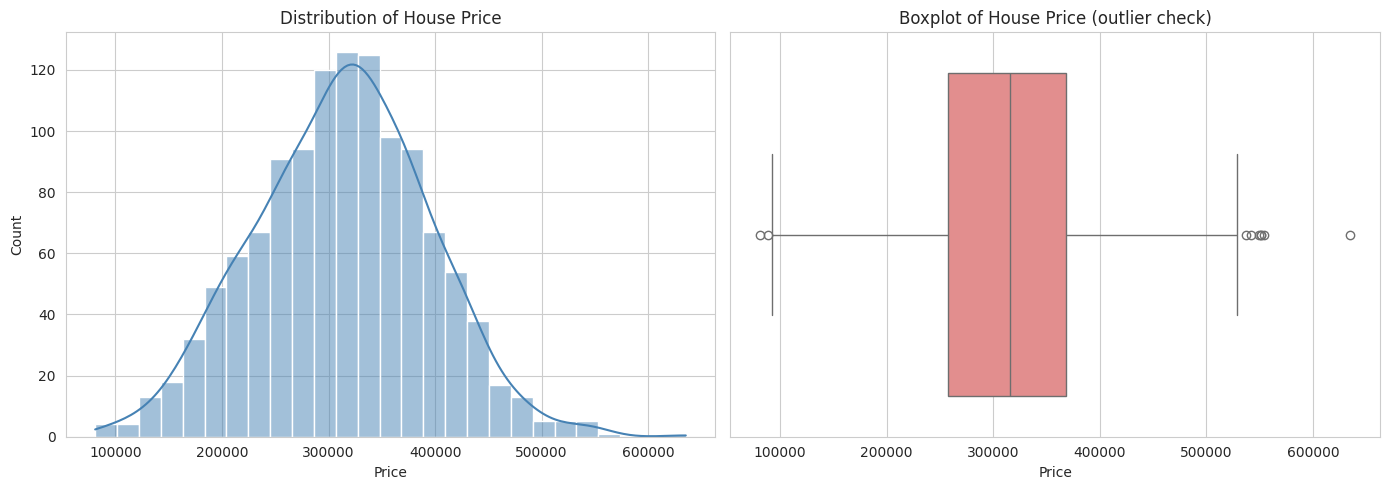

Skewness of Price: 0.02


In [5]:
# --- Distribution of target variable (Price) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["Price"], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of House Price")
axes[0].set_xlabel("Price")

sns.boxplot(x=df["Price"], ax=axes[1], color="lightcoral")
axes[1].set_title("Boxplot of House Price (outlier check)")

plt.tight_layout()
plt.show()

print(f"Skewness of Price: {df['Price'].skew():.2f}")


## 4. Feature Selection Discussion

**Which features are likely to predict house price, and why?**

- **Area / Square footage** — Larger living space almost always commands a higher
  price; this is typically the single strongest numeric predictor of price in
  housing datasets.
- **Location / Neighborhood** — Location captures a huge amount of price variance
  that isn't explained by physical attributes alone (school districts, proximity
  to city center, safety, amenities). It's categorical, so it needs encoding.
- **Number of rooms (bedrooms/bathrooms)** — More rooms generally means more
  usable space and higher value, though this effect is partly correlated with
  area itself (multicollinearity risk worth watching).
- **Age of the house** — Older homes often sell for less due to wear, outdated
  systems, and style, unless they carry historic/renovated value — so we expect
  a negative relationship with price, potentially non-linear.
- **Lot size / Garage spaces** — Extra land and parking are amenities that
  typically increase price, though usually with a smaller effect than living
  area.

**Features we will be cautious about / likely drop:**
- ID-like columns (e.g., row identifiers) — no predictive value, pure noise.
- Columns with excessive missing data (>40-50%) — often better dropped than
  imputed, since imputation could introduce more noise than signal.
- Highly redundant features that are near-duplicates of another column (checked
  via the correlation heatmap in the next section).

This is a hypothesis based on domain knowledge — we'll validate it quantitatively
with the correlation heatmap and the model's coefficients later in the notebook.


## 5. Handle Missing Values & Encode Categorical Features

Strategy:
- **Numeric columns:** impute missing values with the **median** (robust to
  outliers/skew).
- **Categorical columns:** impute missing values with the **mode** (most
  frequent category), then apply **One-Hot Encoding**.
- Drop any column that is more than 50% missing (rarely worth keeping).


In [6]:
df_clean = df.copy()

# Drop columns that are too sparse to be useful
too_sparse = null_summary[null_summary["missing_pct"] > 50].index.tolist()
if too_sparse:
    print(f"Dropping columns >50% missing: {too_sparse}")
    df_clean = df_clean.drop(columns=too_sparse)

numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_clean.select_dtypes(include=["object", "category"]).columns.tolist()

# Target should not be imputed as a feature
if "Price" in numeric_cols:
    numeric_cols.remove("Price")

# Impute numeric columns with median
for col in numeric_cols:
    if df_clean[col].isnull().any():
        median_val = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_val)

# Impute categorical columns with mode
for col in categorical_cols:
    if df_clean[col].isnull().any():
        mode_val = df_clean[col].mode()[0]
        df_clean[col] = df_clean[col].fillna(mode_val)

print("Remaining nulls after imputation:", df_clean.isnull().sum().sum())

# One-Hot Encode categorical features
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

print(f"Shape before encoding: {df_clean.shape}")
print(f"Shape after encoding:  {df_encoded.shape}")
df_encoded.head()


Remaining nulls after imputation: 0
Shape before encoding: (1200, 8)
Shape after encoding:  (1200, 11)


,Area_sqft,Bedrooms,Bathrooms,Age_years,GarageSpaces,LotSize_sqft,Price,Location_Rural,Location_Suburb_A,Location_Suburb_B,Location_Uptown
0,1982.830248,3,2,5,1,2928.566795,323164.0,True,False,False,False
1,1176.009536,2,1,58,2,2707.447069,194864.0,True,False,False,False
2,1806.869019,1,2,19,0,4062.863573,346366.0,False,False,False,True
3,2364.338830,3,2,66,0,4688.389976,402904.0,False,False,False,False
4,629.378887,4,2,41,0,1368.596507,170478.0,False,True,False,False


## 6. Correlation Heatmap

Identify which features are most correlated with `Price`.


Top features correlated with Price:
Area_sqft            0.850125
LotSize_sqft         0.659406
Age_years           -0.281042
Location_Rural      -0.263657
Bedrooms             0.122911
Bathrooms            0.114812
Location_Uptown      0.112694
Location_Suburb_B   -0.048611
GarageSpaces         0.039604
Location_Suburb_A   -0.018328
Name: Price, dtype: float64


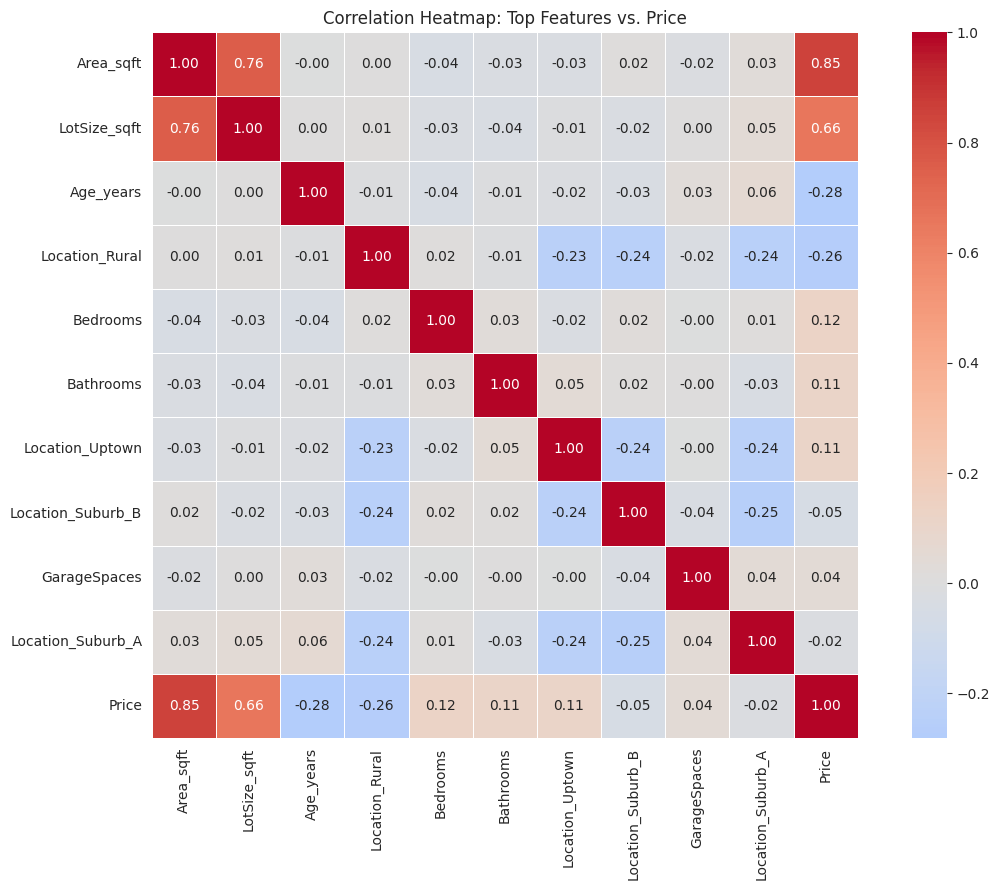

In [7]:
corr_matrix = df_encoded.corr(numeric_only=True)

# Top correlations with Price specifically
price_corr = corr_matrix["Price"].drop("Price").sort_values(key=abs, ascending=False)
print("Top features correlated with Price:")
print(price_corr.head(15))

plt.figure(figsize=(12, 9))
top_features = price_corr.head(12).index.tolist() + ["Price"]
sns.heatmap(df_encoded[top_features].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5)
plt.title("Correlation Heatmap: Top Features vs. Price")
plt.tight_layout()
plt.show()


## 7. Train/Test Split (80/20)

In [8]:
X = df_encoded.drop(columns=["Price"])
y = df_encoded["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set:     {X_test.shape[0]} rows")


Training set: 960 rows
Test set:     240 rows


## 8. Train a Linear Regression Model

In [9]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)

print("Model trained successfully.")


Model trained successfully.


## 9. Model Evaluation: MSE, RMSE, R²

In [10]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE):      {mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
print(f"R² Score:                       {r2:.4f}")
print(f"\nInterpretation: On average, predictions are off by about "
      f"${rmse:,.0f}, and the model explains about {r2*100:.1f}% of the "
      f"variance in house prices.")


Mean Squared Error (MSE):      241,734,822.38
Root Mean Squared Error (RMSE): 15,547.82
R² Score:                       0.9622

Interpretation: On average, predictions are off by about $15,548, and the model explains about 96.2% of the variance in house prices.


## 10. Actual vs. Predicted Prices

The closer the points sit to the diagonal (y = x) line, the better the model.


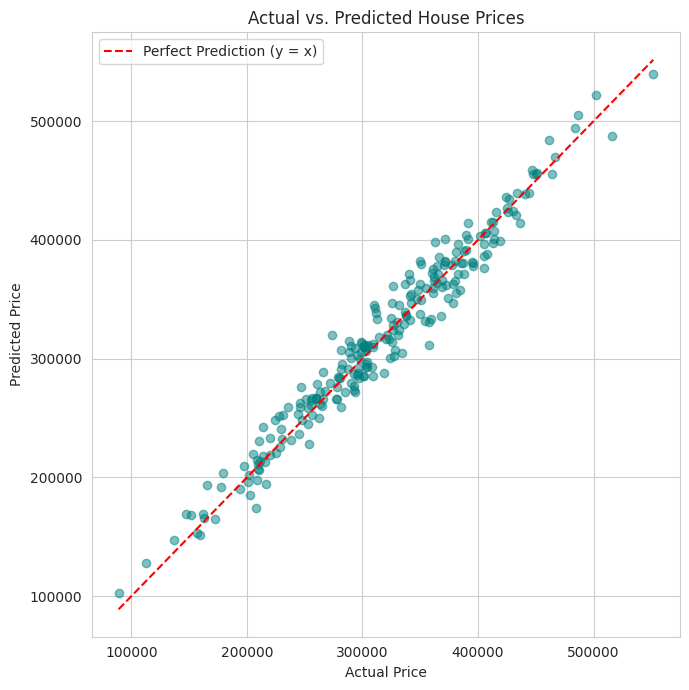

In [11]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.5, color="teal")

lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, "r--", label="Perfect Prediction (y = x)")

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs. Predicted House Prices")
plt.legend()
plt.tight_layout()
plt.show()


## 11. Residual Plot

Residuals = Actual − Predicted. We want these randomly scattered around zero,
with no systematic pattern (a pattern would suggest the model is missing some
non-linear relationship).


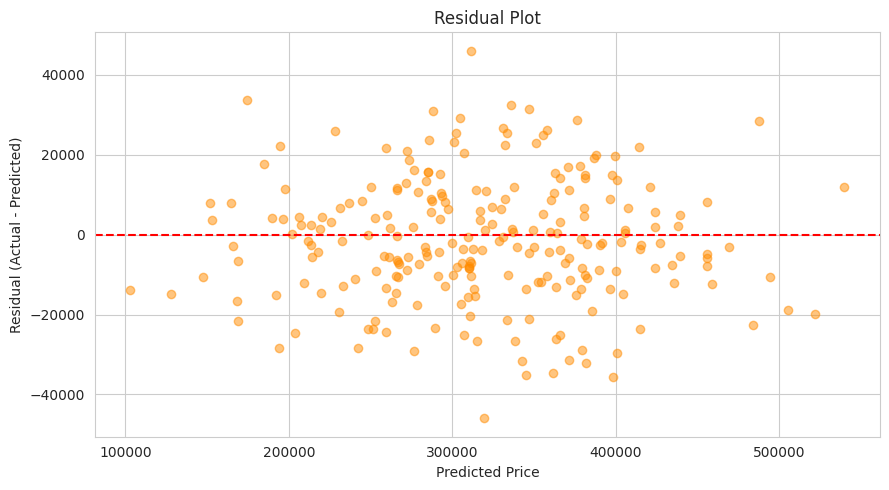

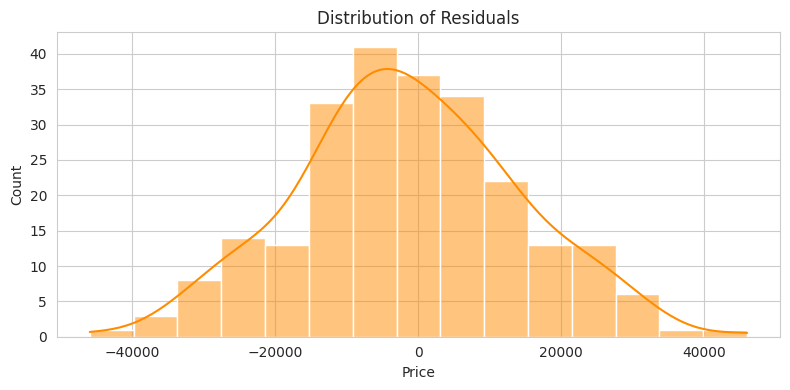

In [12]:
residuals = y_test - y_pred

plt.figure(figsize=(9, 5))
plt.scatter(y_pred, residuals, alpha=0.5, color="darkorange")
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicted Price")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(residuals, kde=True, ax=ax, color="darkorange")
ax.set_title("Distribution of Residuals")
plt.tight_layout()
plt.show()


## 12. Coefficient Analysis

Which features push price up the most, and which push it down?
Note: coefficients are on the original feature scale here, so features with
naturally larger numeric ranges (e.g., square footage) will tend to show
larger-magnitude coefficients than binary one-hot columns — keep that context
in mind when comparing across very different feature types.


Top 10 positive contributors to price:
          Feature   Coefficient
        Bathrooms  12947.429907
         Bedrooms   7742.194801
     GarageSpaces   5127.753901
        Area_sqft    118.428019
     LotSize_sqft      2.512826
        Age_years   -801.623522
  Location_Uptown -13900.150171
Location_Suburb_A -39917.823753
Location_Suburb_B -48049.491945
   Location_Rural -80618.099960

Top 10 negative contributors to price:
          Feature   Coefficient
        Bathrooms  12947.429907
         Bedrooms   7742.194801
     GarageSpaces   5127.753901
        Area_sqft    118.428019
     LotSize_sqft      2.512826
        Age_years   -801.623522
  Location_Uptown -13900.150171
Location_Suburb_A -39917.823753
Location_Suburb_B -48049.491945
   Location_Rural -80618.099960


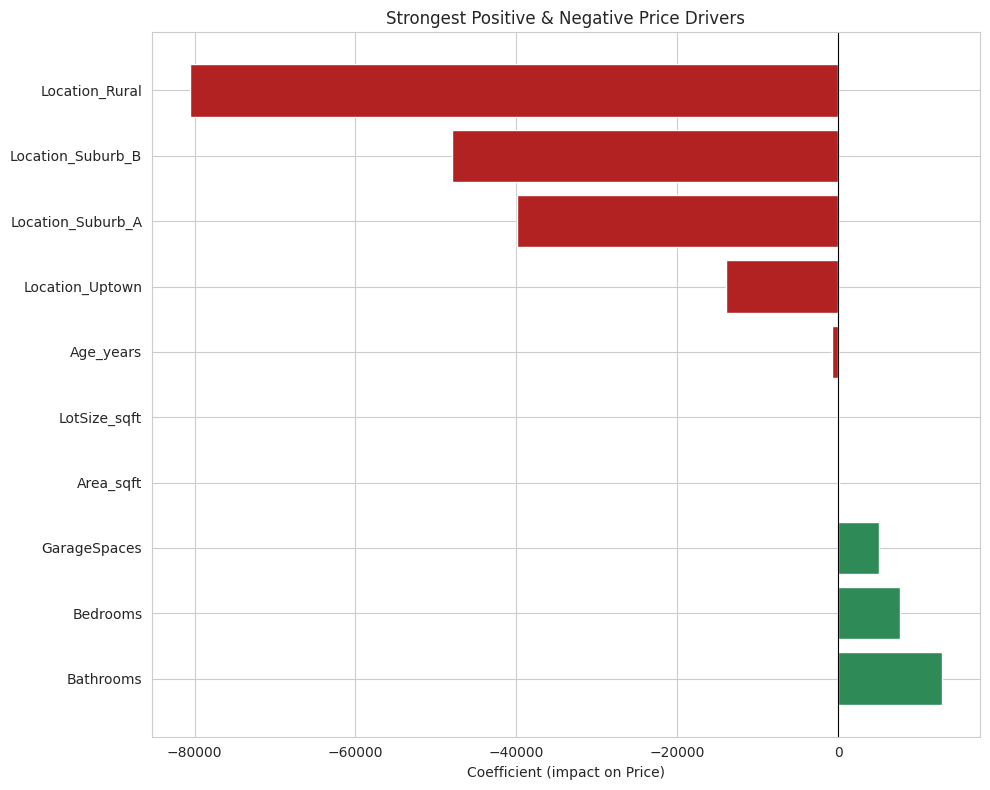

In [13]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_
}).sort_values("Coefficient", ascending=False)

print("Top 10 positive contributors to price:")
print(coef_df.head(10).to_string(index=False))

print("\nTop 10 negative contributors to price:")
print(coef_df.tail(10).to_string(index=False))

plt.figure(figsize=(10, 8))
top_n = pd.concat([coef_df.head(8), coef_df.tail(8)])
colors = ["seagreen" if c > 0 else "firebrick" for c in top_n["Coefficient"]]
plt.barh(top_n["Feature"], top_n["Coefficient"], color=colors)
plt.axvline(x=0, color="black", linewidth=0.8)
plt.xlabel("Coefficient (impact on Price)")
plt.title("Strongest Positive & Negative Price Drivers")
plt.tight_layout()
plt.show()


## 13. (Bonus) Comparing Linear Regression vs. Ridge and Lasso

Ridge (L2) and Lasso (L1) add regularization to reduce overfitting, especially
useful when features are correlated with each other (multicollinearity).


In [14]:
ridge_model = Ridge(alpha=1.0, random_state=RANDOM_STATE)
ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)

lasso_model = Lasso(alpha=1.0, random_state=RANDOM_STATE, max_iter=10000)
lasso_model.fit(X_train, y_train)
lasso_pred = lasso_model.predict(X_test)

def evaluate(name, y_true, y_pred_):
    mse_ = mean_squared_error(y_true, y_pred_)
    rmse_ = np.sqrt(mse_)
    r2_ = r2_score(y_true, y_pred_)
    return {"Model": name, "MSE": mse_, "RMSE": rmse_, "R2": r2_}

results = pd.DataFrame([
    evaluate("Linear Regression", y_test, y_pred),
    evaluate("Ridge Regression", y_test, ridge_pred),
    evaluate("Lasso Regression", y_test, lasso_pred),
])

results


,Model,MSE,RMSE,R2
0,Linear Regression,2.417348e+08,15547.823719,0.962213
1,Ridge Regression,2.421655e+08,15561.667506,0.962146
2,Lasso Regression,2.417323e+08,15547.743159,0.962214


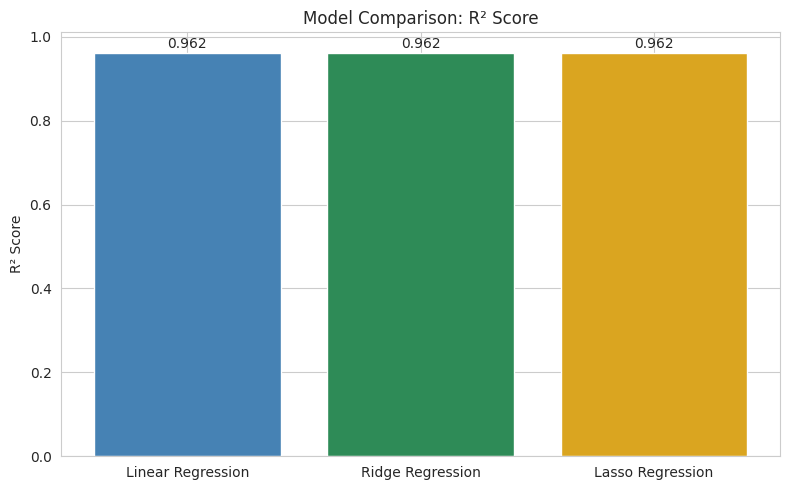

Number of features Lasso zeroed out (feature selection effect): 0 out of 10


In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(results["Model"], results["R2"], color=["steelblue", "seagreen", "goldenrod"])
ax.set_ylabel("R² Score")
ax.set_title("Model Comparison: R² Score")
for i, v in enumerate(results["R2"]):
    ax.text(i, v + 0.01, f"{v:.3f}", ha="center")
plt.tight_layout()
plt.show()

print("Number of features Lasso zeroed out (feature selection effect):",
      (lasso_model.coef_ == 0).sum(), "out of", len(lasso_model.coef_))


## 14. Conclusion

- Summarize which features matter most (refer back to Section 12).
- Note the model's overall accuracy (RMSE, R²) and what that means practically
  for use in a real pricing tool.
- If using the synthetic dataset, re-run everything with the real Kaggle
  `train.csv` for genuine conclusions — the synthetic data is only meant to
  demonstrate the pipeline.
- Possible next steps: try polynomial features, feature engineering
  (e.g., price per sqft), tree-based models (Random Forest / XGBoost) for
  comparison, or cross-validation for more robust evaluation.
